#  Week 4: Logistic Regression and Feature Scaling

## 1. Notebook Setup
- Import libraries  
- Define helper functions for model evaluation and scaling

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Helper: evaluate logistic regression model
def evaluate_logistic(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    return {"Accuracy": acc, "Confusion Matrix": cm, "Report": report}


## 2. Dataset 1: customer_churn
### 2.1 Data Overview & Preparation

In [2]:
#load data
train_cc = pd.read_csv('customer_churn_dataset-training-master.csv')
test_cc = pd.read_csv('customer_churn_dataset-testing-master.csv')
#combine train and test set
customer_churn = pd.concat([train_cc, test_cc], ignore_index=True)
#drop null rows
customer_churn.dropna(inplace=True)
X = pd.get_dummies(customer_churn.drop("Churn", axis=1, errors="ignore"), drop_first=True)
y = customer_churn["Churn"] if "Churn" in customer_churn.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 2.2 Feature Scaling (Standardization & Normalization)

In [3]:
if y is not None:
    scaler_standard = StandardScaler()
    X_train_std = scaler_standard.fit_transform(X_train)
    X_test_std = scaler_standard.transform(X_test)

    scaler_minmax = MinMaxScaler()
    X_train_minmax = scaler_minmax.fit_transform(X_train)
    X_test_minmax = scaler_minmax.transform(X_test)

### 2.3 Logistic Regression with Standard Scaled Data

In [4]:
if y is not None:
    log_reg_std = LogisticRegression(max_iter=1000)
    results_std = evaluate_logistic(log_reg_std, X_train_std, X_test_std, y_train, y_test)
    print("Logistic Regression (Standard Scaling):", results_std)

Logistic Regression (Standard Scaling): {'Accuracy': 0.8831179113635914, 'Confusion Matrix': array([[38124,  6857],
       [ 4953, 51108]]), 'Report': '              precision    recall  f1-score   support\n\n         0.0       0.89      0.85      0.87     44981\n         1.0       0.88      0.91      0.90     56061\n\n    accuracy                           0.88    101042\n   macro avg       0.88      0.88      0.88    101042\nweighted avg       0.88      0.88      0.88    101042\n'}


### 2.4 Logistic Regression with Min-Max Scaled Data

In [5]:
if y is not None:
    log_reg_mm = LogisticRegression(max_iter=1000)
    results_mm = evaluate_logistic(log_reg_mm, X_train_minmax, X_test_minmax, y_train, y_test)
    print("Logistic Regression (Min-Max Scaling):", results_mm)

Logistic Regression (Min-Max Scaling): {'Accuracy': 0.8830387363670553, 'Confusion Matrix': array([[38131,  6850],
       [ 4968, 51093]]), 'Report': '              precision    recall  f1-score   support\n\n         0.0       0.88      0.85      0.87     44981\n         1.0       0.88      0.91      0.90     56061\n\n    accuracy                           0.88    101042\n   macro avg       0.88      0.88      0.88    101042\nweighted avg       0.88      0.88      0.88    101042\n'}


#### Relevant plots:
ROC curve

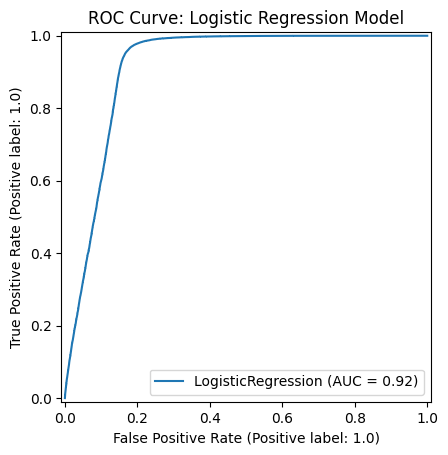

In [10]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(log_reg_std, X_test_std, y_test)
plt.title("ROC Curve: Logistic Regression Model")
plt.show()

Confusion matrix:

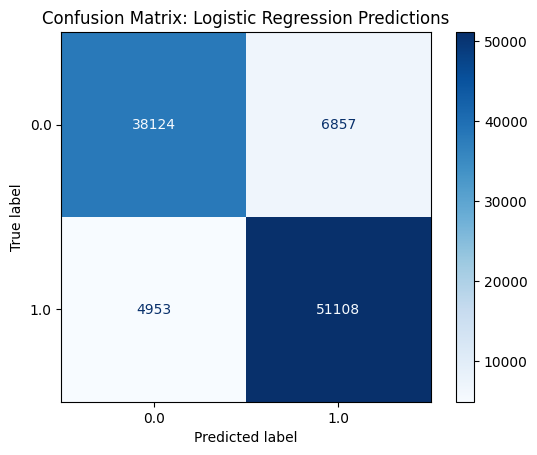

In [13]:
ConfusionMatrixDisplay.from_estimator(log_reg_std, X_test_std, y_test, cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression Predictions")
plt.show()

## 3. Dataset 2: digital_marketing_campaign
### 3.1 Data Overview & Preparation

In [14]:
digital_marketing = pd.read_csv("digital_marketing_campaign_dataset.csv")
digital_marketing.dropna(inplace=True)
X = pd.get_dummies(digital_marketing.drop("Conversion", axis=1, errors="ignore"), drop_first=True)
y = digital_marketing["Conversion"] if "Conversion" in digital_marketing.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3.2 Feature Scaling (Standardization & Normalization)

In [15]:
if y is not None:
    scaler_standard = StandardScaler()
    X_train_std = scaler_standard.fit_transform(X_train)
    X_test_std = scaler_standard.transform(X_test)

    scaler_minmax = MinMaxScaler()
    X_train_minmax = scaler_minmax.fit_transform(X_train)
    X_test_minmax = scaler_minmax.transform(X_test)

### 3.3 Logistic Regression with Standard Scaled Data

In [16]:
if y is not None:
    log_reg_std = LogisticRegression(max_iter=1000)
    results_std = evaluate_logistic(log_reg_std, X_train_std, X_test_std, y_train, y_test)
    print("Logistic Regression (Standard Scaling):", results_std)

Logistic Regression (Standard Scaling): {'Accuracy': 0.874375, 'Confusion Matrix': array([[  35,  159],
       [  42, 1364]]), 'Report': '              precision    recall  f1-score   support\n\n           0       0.45      0.18      0.26       194\n           1       0.90      0.97      0.93      1406\n\n    accuracy                           0.87      1600\n   macro avg       0.68      0.58      0.59      1600\nweighted avg       0.84      0.87      0.85      1600\n'}


### 3.4 Logistic Regression with Min-Max Scaled Data

In [17]:
if y is not None:
    log_reg_mm = LogisticRegression(max_iter=1000)
    results_mm = evaluate_logistic(log_reg_mm, X_train_minmax, X_test_minmax, y_train, y_test)
    print("Logistic Regression (Min-Max Scaling):", results_mm)

Logistic Regression (Min-Max Scaling): {'Accuracy': 0.873125, 'Confusion Matrix': array([[  31,  163],
       [  40, 1366]]), 'Report': '              precision    recall  f1-score   support\n\n           0       0.44      0.16      0.23       194\n           1       0.89      0.97      0.93      1406\n\n    accuracy                           0.87      1600\n   macro avg       0.67      0.57      0.58      1600\nweighted avg       0.84      0.87      0.85      1600\n'}


### 3.5 Insights
- The Standard Scaled Data and the Min-Max Scaled Data models produced similar accuracy score, with the Scaled Data having a slightly larger f1 score.

#### Relevant plots:
ROC Curve:

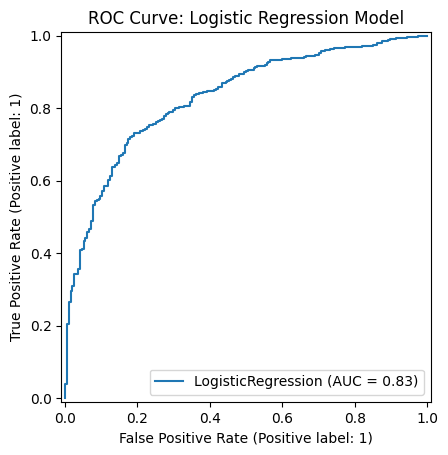

In [18]:
RocCurveDisplay.from_estimator(log_reg_std, X_test_std, y_test)
plt.title("ROC Curve: Logistic Regression Model")
plt.show()

Confusion Matrix:

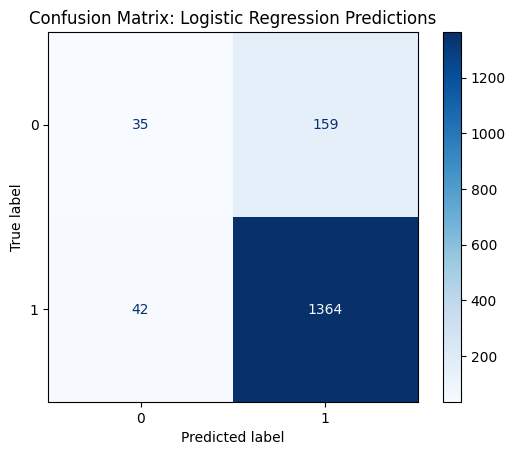

In [19]:
ConfusionMatrixDisplay.from_estimator(log_reg_std, X_test_std, y_test, cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression Predictions")
plt.show()

## 4. Dataset 3: marketing_campaign (Optional for Week 4)
### 4.1 Data Overview & Preparation

In [20]:
marketing_campaign = pd.read_csv("marketing_campaign.csv", sep=';')
marketing_campaign.dropna(inplace=True)
X = pd.get_dummies(marketing_campaign.drop("Response", axis=1, errors="ignore"), drop_first=True)
y = marketing_campaign["Response"] if "Response" in marketing_campaign.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 4.2 Feature Scaling (Standardization & Normalization)

In [21]:
if y is not None:
    scaler_standard = StandardScaler()
    X_train_std = scaler_standard.fit_transform(X_train)
    X_test_std = scaler_standard.transform(X_test)

    scaler_minmax = MinMaxScaler()
    X_train_minmax = scaler_minmax.fit_transform(X_train)
    X_test_minmax = scaler_minmax.transform(X_test)

### 4.3 Logistic Regression with Standard Scaled Data

In [22]:
if y is not None:
    log_reg_std = LogisticRegression(max_iter=1000)
    results_std = evaluate_logistic(log_reg_std, X_train_std, X_test_std, y_train, y_test)
    print("Logistic Regression (Standard Scaling):", results_std)

Logistic Regression (Standard Scaling): {'Accuracy': 0.8490990990990991, 'Confusion Matrix': array([[352,  30],
       [ 37,  25]]), 'Report': '              precision    recall  f1-score   support\n\n           0       0.90      0.92      0.91       382\n           1       0.45      0.40      0.43        62\n\n    accuracy                           0.85       444\n   macro avg       0.68      0.66      0.67       444\nweighted avg       0.84      0.85      0.85       444\n'}


### 4.4 Logistic Regression with Min-Max Scaled Data

In [23]:
if y is not None:
    log_reg_mm = LogisticRegression(max_iter=1000)
    results_mm = evaluate_logistic(log_reg_mm, X_train_minmax, X_test_minmax, y_train, y_test)
    print("Logistic Regression (Min-Max Scaling):", results_mm)

Logistic Regression (Min-Max Scaling): {'Accuracy': 0.8896396396396397, 'Confusion Matrix': array([[370,  12],
       [ 37,  25]]), 'Report': '              precision    recall  f1-score   support\n\n           0       0.91      0.97      0.94       382\n           1       0.68      0.40      0.51        62\n\n    accuracy                           0.89       444\n   macro avg       0.79      0.69      0.72       444\nweighted avg       0.88      0.89      0.88       444\n'}


### 4.5 Insights
- The Standard Scaled Data and the Min-Max Scaled Data models produced similar accuracy score, with the Scaled Data having a slightly larger f1 score.

#### Relevant plots:
ROC Curve

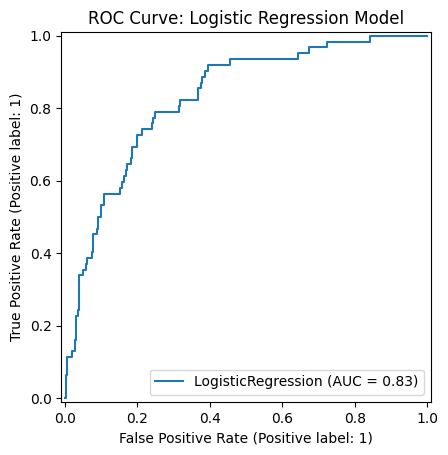

In [24]:
RocCurveDisplay.from_estimator(log_reg_std, X_test_std, y_test)
plt.title("ROC Curve: Logistic Regression Model")
plt.show()

Confusion Matrix:

/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


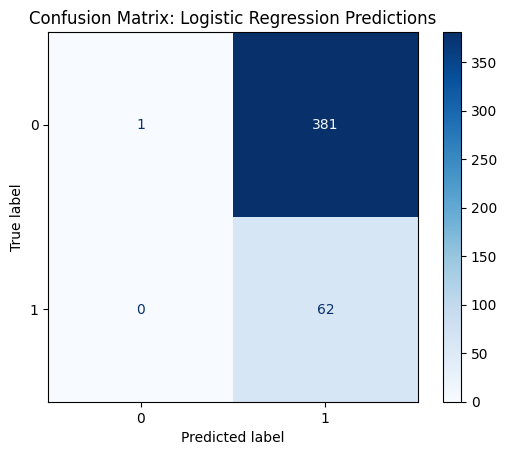

In [25]:
ConfusionMatrixDisplay.from_estimator(log_reg_std, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression Predictions")
plt.show()